<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2027-1/notebooks/1b_neurona_lineal_descenso_gradiente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neurona artificial para regresión mediante descenso por gradiente
En esta libreta programaremos y evaluaremos el algoritmo de descenso por gradiente para entrenar una neurona artificial en un problema de regresión.

In [1]:
import numpy as np
import torch as th

import pandas as pd
import matplotlib.pyplot as plt

# por reproducibilidad
np.random.seed(42)
th.manual_seed(42)

## Conjunto de datos
Usaremos el conjunto de datos _SAT and College GPA_ para entrenar y evaluar un modelo de regresión del promedio general de un alumno de licenciatura a partir de otros promedios o calificaciones. Dicho conjunto se encuentra disponible en [http://onlinestatbook.com/2/case_studies/sat.html](http://onlinestatbook.com/2/case_studies/sat.html) y cuenta con las siguientes variables:

Campo | Descripción
--|--
high_GPA | High school grade point average
math_SAT | Math SAT score
verb_SAT | Verbal SAT score
comp_GPA | Computer science grade point average
univ_GPA | Overall university grade point average


Cargamos el conjunto de datos como un `DataFrame` usando Pandas y examinamos los primeros ejemplos.

In [2]:
sat = pd.read_csv('http://onlinestatbook.com/2/case_studies/data/sat.txt', sep=' ')
sat.head(5)

,high_GPA,math_SAT,verb_SAT,comp_GPA,univ_GPA
0,3.45,643,589,3.76,3.52
1,2.78,558,512,2.87,2.91
2,2.52,583,503,2.54,2.40
3,3.67,685,602,3.83,3.47
4,3.24,592,538,3.29,3.47


## Partición del conjunto de datos
Dividimos  aleatoriamente el conjunto de datos en 80% para entrenamiento y 20% para validación.


In [3]:
n_ejemplos = sat.shape[0]
permutacion = np.random.permutation(n_ejemplos)

conj_ent = permutacion[:int(n_ejemplos * 0.8)]
conj_val = permutacion[int(n_ejemplos * 0.8):]

n_ent = conj_ent.shape[0]
n_val = conj_val.shape[0]

Usaremos solo el atributo Computer Science GPA (columna `comp_GPA`) como regresor para el University GPA (columna `univ_GPA`), los cuales convertimos en arreglos de NumPY.


In [4]:
X_ent = sat.comp_GPA[conj_ent].to_numpy()
y_ent = sat.univ_GPA[conj_ent].to_numpy()

X_val = sat.comp_GPA[conj_val].to_numpy()
y_val = sat.univ_GPA[conj_val].to_numpy()

X_rango = np.arange(2.0, 4.0, 0.01)

A su vez, convertimos los arreglos de NumPy en tensores de PyTorch.

In [5]:
X_ent = th.tensor(X_ent[:, np.newaxis], dtype = th.float32)
y_ent = th.tensor(y_ent[:, np.newaxis], dtype = th.float32)

X_val = th.tensor(X_val[:, np.newaxis], dtype = th.float32)
y_val = th.tensor(y_val[:, np.newaxis], dtype = th.float32)

X_rango = th.tensor(X_rango[:, np.newaxis], dtype = th.float32)

## Preprocesamiento
Escalamos los valores del atributo usando estandarización:

$$
x' = \frac{x - \mu}{\sigma}
$$

In [6]:
mu = X_ent.mean(axis=0)
sigma = X_ent.std(axis=0, unbiased=True)

X_ent = (X_ent - mu) / sigma
X_val = (X_val - mu) / sigma
X_rango = (X_rango - mu) / sigma

## Neurona artificial y función de pérdida
Definimos la operación de la neurona artificial sin función de activación.

In [7]:
neurona_lineal = lambda x, w, b: b + x @ w

Definimos la métrica de error cuadrático medio:

$$
ECM(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{n}\sum_{i=1}^n \left(\hat{y}^{(i)} - y^{(i)}\right)^2
$$

In [8]:
ecm = lambda y_pred, y: ((y_pred - y)**2).mean()

## Descenso por gradiente
Vamos a entrenar a la neurona artificial lineal usando descenso por gradiente. En particular, buscamos minimizar:
$$
\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{2\cdot n} \sum_{i = 1} ^n \left(\hat{y}^{(i)} - y^{(i)}\right)^2
$$

El gradiente de esta función de pérdida respecto a los pesos $\mathbf{w} \in \mathbb{R}^{d\times 1}$ está dado por

$$
\nabla_{\mathbf{w}} \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \left[\frac{\partial \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})}{\partial w_1}, \frac{\partial \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})}{\partial w_2}, \cdots, \frac{\partial \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})}{\partial w_d}\right]^\top
$$

donde

$$
\frac{\partial \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})}{\partial w_j} = \frac{1}{n}\cdot  \sum_{i=1}^n \left[ \left(\hat{y}^{(i)} - y^{(i)}\right) \cdot x_j^{(i)} \right]
$$

que en forma vectorial se expresa como

$$
\nabla_{\mathbf{w}} \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{n} \mathbf{X}^\top \left(\hat{\mathbf{y}} - \mathbf{y}\right)
$$

In [9]:
def grad_w(X, y_pred, y):
  return X.T @ (y_pred - y) / X.shape[0]

Por su parte, la derivada parcial de la función de pérdida respecto al sesgo $b\in \mathbb{R}$ es

$$
\frac{\partial \mathcal{L}(\hat{\mathbf{y}}, \mathbf{y})}{\partial b} = \frac{1}{n}\cdot \sum_{i=1}^n \left(\hat{y}^{(i)} - y^{(i)}\right)
$$


In [10]:
def grad_b(X, y_pred, y):
  return (y_pred - y).mean()

El algoritmo del descenso por gradiente quedaría como sigue:

In [11]:
def descenso_gradiente(X_ent,
                       y_ent,
                       X_val,
                       y_val,
                       n_epocas = 10,
                       alfa = 0.001):
  # Inicializamos los pesos y el sesgo con números aleatorios
  w = th.rand(X_ent.shape[1], 1)
  b = th.rand(1)

  hist = {'ent': th.zeros(n_epocas),
          'val': th.zeros(n_epocas)}
  for e in range(n_epocas):
    # Obtenemos predicciones con los pesos y el sesgo actuales
    y_pred =  neurona_lineal(X_ent, w, b)

    # Actualizamos los pesos y el sesgo
    w = w - alfa * grad_w(X_ent, y_pred, y_ent)
    b = b - alfa * grad_b(X_ent, y_pred, y_ent)

    # evaluamos tanto en el subconjunto de entrenamiento
    # como en el de validación al finalizar la época
    y_pred =  neurona_lineal(X_ent, w, b)
    hist['ent'][e] = ecm(y_pred, y_ent)

    y_pred_val =  neurona_lineal(X_val, w, b)
    hist['val'][e] = ecm(y_pred_val, y_val)

  return w, b, hist

## Entrenamiento mediante descenso por gradiente
Entrenamos nuestro modelo de regresión lineal con este algoritmo por 50 épocas con una tasa de aprendizaje de 0.1.

In [12]:
alfa = 0.1
n_epocas = 50
w_gd, b_gd, hist_gd = descenso_gradiente(X_ent,
                                         y_ent,
                                         X_val,
                                         y_val,
                                         n_epocas = n_epocas,
                                         alfa = alfa)

Graficamos el error cuadrático medio en cada época. Nótese que la función que
optimizamos y la métrica con que evaluamos difieren en el factor $\frac{1}{2}$:

$$
\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{2\cdot n} \sum_{i = 1} ^n \left(\hat{y}^{(i)} - y^{(i)}\right)^2
\qquad\text{frente a}\qquad
ECM(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{n} \sum_{i = 1} ^n \left(\hat{y}^{(i)} - y^{(i)}\right)^2
$$

Este factor en $\mathcal{L}$ se incluye únicamente por conveniencia algebraica, ya que cancela el $2$ de la derivada del término cuadrático, simplificando la expresión del gradiente. Al ser una constante positiva, no modifica los parámetros que minimizan la función.

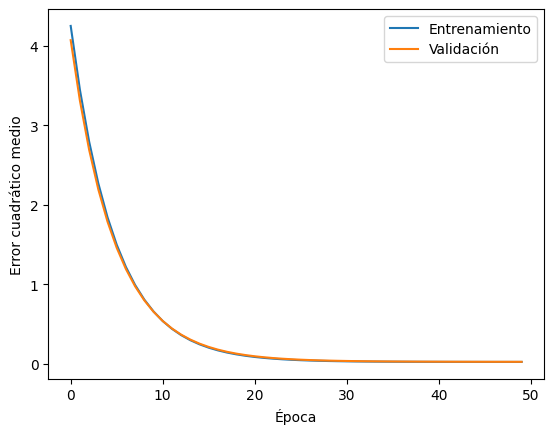

In [13]:
plt.plot(hist_gd['ent'], label = u'Entrenamiento')
plt.plot(hist_gd['val'], label = u'Validación')
plt.legend()
plt.xlabel(u'Época')
plt.ylabel(u'Error cuadrático medio')
plt.show()

## Descenso por gradiente estocástico
En el descenso por gradiente estocástico (SGD, por sus siglas en inglés) se estima el gradiente y se actualizan los pesos y sesgos con un minilote de ejemplos de entrenamiento, en lugar de hacerlo con todos los ejemplos. En SGD, es común generar una permutación aleatoria del subconjunto de $n$ ejemplos de entrenamiento y dividirlo en $k$ minilotes $\mathcal{B}$, donde el tamaño del minilote es un hiperparámetro ($\vert \mathcal{B} \vert \times k \approx n$). Así, una época ocurre cada vez que se han considerado los $k$ minilotes del subconjunto de entrenamiento.

In [14]:
def descenso_gradiente_estocastico(X_ent,
                                   y_ent,
                                   X_val,
                                   y_val,
                                   t_lote = 20,
                                   n_epocas = 10,
                                   alfa = 0.001):
  # Inicializamos los pesos y el sesgo con números aleatorios
  w = th.rand(X_ent.shape[1], 1)
  b = th.rand(1)

  n_lotes = int(X_ent.shape[0] / t_lote)
  hist = {'ent': th.zeros(n_epocas),
          'val': th.zeros(n_epocas)}
  for e in range(n_epocas):
    # Permutación aleatoria con la que se tomarán los lotes de la época
    perm = np.random.permutation(X_ent.shape[0])
    for l in range(n_lotes):
      # Se toma el lote l-ésimo
      Xlote = X_ent[perm[l * t_lote:(l + 1) * t_lote]]
      ylote = y_ent[perm[l * t_lote:(l + 1) * t_lote]]

      # Obtenemos predicciones con los pesos y el sesgo actuales
      y_pred =  neurona_lineal(Xlote, w, b)

      # Actualizamos los pesos y el sesgo
      w = w - alfa * grad_w(Xlote, y_pred, ylote)
      b = b - alfa * grad_b(Xlote, y_pred, ylote)

    # evaluamos tanto en el subconjunto de entrenamiento
    # como en el de validación al finalizar la época
    y_pred =  neurona_lineal(X_ent, w, b)
    hist['ent'][e] = ecm(y_pred, y_ent)

    y_pred_val =  neurona_lineal(X_val, w, b)
    hist['val'][e] = ecm(y_pred_val, y_val)

  return w, b, hist

## Entrenamiento mediante descenso por gradiente estocástico
Entrenamos otro modelo usando SGD por 50 épocas con lotes de 16 ejemplos y una tasa de aprendizaje de 0.1.

In [15]:
t_lote = 16
w_sgd, b_sgd, hist_sgd = descenso_gradiente_estocastico(X_ent,
                                                        y_ent,
                                                        X_val,
                                                        y_val,
                                                        t_lote = t_lote,
                                                        n_epocas = n_epocas,
                                                        alfa = alfa)

Graficamos el error cuadrático medio en cada época.

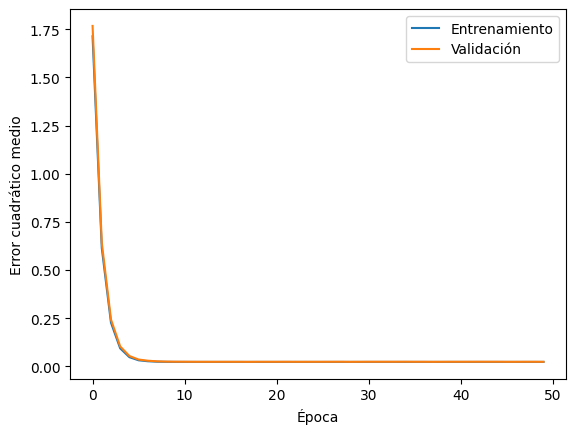

In [16]:
plt.plot(hist_sgd['ent'], label = u'Entrenamiento')
plt.plot(hist_sgd['val'], label = u'Validación')
plt.xlabel(u'Época')
plt.ylabel(u'Error cuadrático medio')
plt.legend()
plt.show()

## Modelos entrenados
Visualizamos las rectas ajustadas por cada algoritmo.

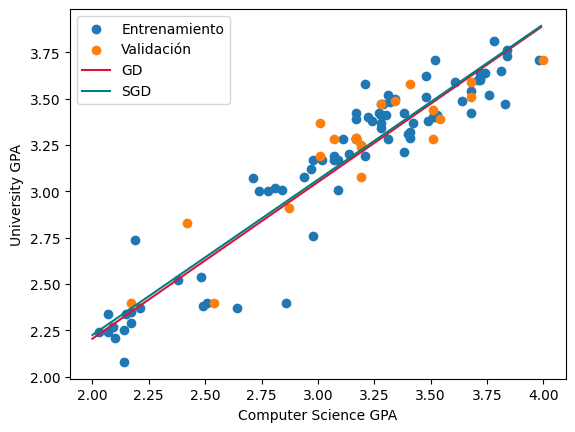

In [17]:
pred_gd = neurona_lineal(X_rango, w_gd, b_gd)
pred_sgd = neurona_lineal(X_rango, w_sgd, b_sgd)

plt.scatter(X_ent * sigma + mu, y_ent, label = u'Entrenamiento')
plt.scatter(X_val * sigma + mu, y_val, label = u'Validación')
plt.plot(X_rango * sigma + mu, pred_gd, label = u'GD', color = 'crimson')
plt.plot(X_rango * sigma + mu, pred_sgd, label = u'SGD', color = 'teal')
plt.xlabel(u'Computer Science GPA')
plt.ylabel(u'University GPA')
plt.legend()
plt.show()

Los errores cuadráticos medios de ambos modelos para entrenamiento y validación son:

In [18]:
ecm_ent_gd = ecm(neurona_lineal(X_ent, w_gd, b_gd), y_ent)
ecm_val_gd = ecm(neurona_lineal(X_val, w_gd, b_gd), y_val)
ecm_ent_sgd = ecm(neurona_lineal(X_ent, w_sgd, b_sgd), y_ent)
ecm_val_sgd = ecm(neurona_lineal(X_val, w_sgd, b_sgd), y_val)

print(f'ECM GD  --- Ent: {ecm_ent_gd:.5f}, Val: {ecm_val_gd:.5f}\n'
      f'ECM SGD --- Ent: {ecm_ent_sgd:.5f}, Val: {ecm_val_sgd:.5f}')

ECM GD  --- Ent: 0.02348, Val: 0.02472
ECM SGD --- Ent: 0.02335, Val: 0.02392
